In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")



In [48]:
df = pd.read_csv('/content/train.csv')
df1 = pd.read_csv('/content/test.csv')
df.update(df1)

print(df)


        trip_duration  distance_traveled  num_of_passengers    fare  tip  \
0              1076.0               4.18                1.0    0.00    0   
1               429.0               1.48                4.0    0.00    0   
2               856.0               4.15                1.0    0.00   24   
3               622.0               3.22                1.0    0.00   15   
4               507.0               3.98                1.0    0.00    0   
...               ...                ...                ...     ...  ...   
209668         1617.0               8.42                1.0  150.00   47   
209669          438.0               1.29                1.0   48.75   12   
209670          571.0               2.82                1.0   63.75    0   
209671          491.0               2.16                1.0   56.25    0   
209672         3614.0              33.72                1.0  337.50    0   

        miscellaneous_fees  total_fare  surge_applied  
0                   13.500     

In [54]:
df = pd.read_csv('/content/train.csv')
df1 = pd.read_csv('/content/test.csv')
df.update(df1)

y = df['surge_applied']
x = df.drop(['surge_applied'], axis = 1) # Removed inplace=True and assigned the result to x


scaler = StandardScaler()
Le = LabelEncoder()

for col in x:
  if x[col].dtype == "float64":
    x[col] = x[col].astype(int)
  elif x[col].dtype == "object":
    x[col] = Le.fit_transform(x[col])
  elif x[col].dtype == "int64" and col == "xyz_campaign_id" or col == "fb_campaign_id":
    x[col] = Le.fit_transform(x[col])
  else:
    x[col] = scaler.fit_transform(x[col].values.reshape(-1, 1))

In [57]:
print(x)

        trip_duration  distance_traveled  num_of_passengers  fare       tip  \
0                1076                  4                  1     0 -0.656013   
1                 429                  1                  4     0 -0.656013   
2                 856                  4                  1     0  0.549064   
3                 622                  3                  1     0  0.097160   
4                 507                  3                  1     0 -0.656013   
...               ...                ...                ...   ...       ...   
209668           1617                  8                  1   150  1.703930   
209669            438                  1                  1    48 -0.053474   
209670            571                  2                  1    63 -0.656013   
209671            491                  2                  1    56 -0.656013   
209672           3614                 33                  1   337 -0.656013   

        miscellaneous_fees  total_fare  
0         

In [58]:
y.value_counts()

,count
surge_applied,
0,150556
1,59117


In [59]:

smote = SMOTE()
x, y = smote.fit_resample(x, y)

y.value_counts()

,count
surge_applied,
0,150556
1,150556


In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1 )

xgb_model.fit(x_train, y_train_encoded)
y_pred_encoded = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
# For multi-class, precision, recall, f1_score need an 'average' parameter
precision = precision_score(y_test_encoded, y_pred_encoded, average='weighted')
recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')

print(f"""
accuracy : {accuracy}
precision : {precision}
recall : {recall}
f1_score : {f1}
""")


accuracy : 0.9988044434850473
precision : 0.99880447749667
recall : 0.9988044434850473
f1_score : 0.9988044428653069



In [62]:
y_train.value_counts()

,count
surge_applied,
0,120558
1,120331


In [63]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_encoded, y_pred_encoded))
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
print(cm)
# generate confusion matrix code

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29998
           1       1.00      1.00      1.00     30225

    accuracy                           1.00     60223
   macro avg       1.00      1.00      1.00     60223
weighted avg       1.00      1.00      1.00     60223

[[29958    40]
 [   32 30193]]


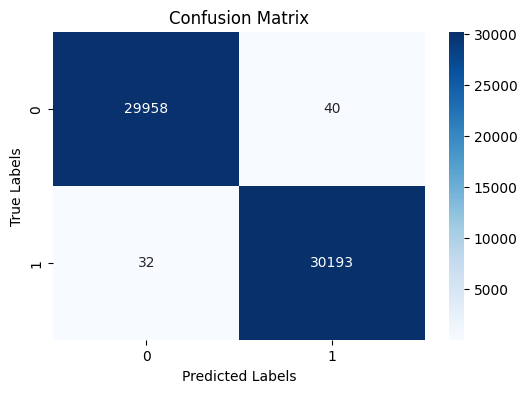

              feature  importance
5  miscellaneous_fees    0.800126
6          total_fare    0.061894
3                fare    0.061777
4                 tip    0.050970
1   distance_traveled    0.011898
0       trip_duration    0.009239
2   num_of_passengers    0.004096


['fraud_detection_model.pkl']

In [64]:
plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_encoded), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({'feature': x.columns, 'importance': importance})
print(feature_importance.sort_values(by = 'importance', ascending = False))


import joblib

joblib.dump(xgb_model, "fraud_detection_model.pkl")

In [65]:
import joblib
joblib.dump(xgb_model, 'taxi fare surge model.pkl')
print(f" saved model")

 saved model
